In [1]:
# Training name
training_name = 'Transformer120e_2bit'

# Gaussian noise parameters
NOISE_MU = 0.0
NOISE_SIGMA = 80.0 # e-

# Precision of input data
N_BITS = 2

In [2]:
# IMPORTS ---------------------------------------------------------------------

import warnings
warnings.filterwarnings("ignore")

import os, subprocess
from pathlib import Path
import random

from keras.utils import Sequence
from keras.callbacks import CSVLogger
from keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
colors = list(mcolors.TABLEAU_COLORS.keys())

from models import *
from plotting import *

2026-05-19 14:25:35.674062: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-19 14:25:35.787554: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
# DATA ---------------------------------------------------------------------

dataset_base_dir = "/uscms/home/bweiss/nobackup/smart-pixels/"
tfrecords_base_dir = "/uscms/home/jennetd/nobackup/smart-pixels/tfrecords"

dataset_dir_val = os.path.join(dataset_base_dir, "dataset_3sr_16x16_50x12P5_centeredIncidence_parquets", 'test_contained/')

In [4]:
fingerprint = '923bc2f5'

In [5]:
base_dir = '/uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-'+fingerprint+'-'+training_name+'-checkpoints/'
        
checkpoint_dir = base_dir + 'checkpoints/'
checkpoint_files = [os.path.join(checkpoint_dir, f) for f in os.listdir(checkpoint_dir) if f.endswith('.hdf5')]
#latest_checkpoint = max(checkpoint_files, key=os.path.getmtime)
    
checkpoint_val_loss = [float(f.split('-v')[1].split('.hdf5')[0]) for f in checkpoint_files]                      
best_checkpoint = checkpoint_files[np.argmin(checkpoint_val_loss)]
os.system('cp '+best_checkpoint+' ' +base_dir)

best_epoch = int(best_checkpoint.split('weights.')[1].split('-t')[0])

model = create_vit_model(input_shape=(16,16,2),   
                         patch_size=(3,4),        
                         embed_dim=64,           
                         num_heads=4,            
                         ff_dim=128,              
                         num_layers=4,            
                         dropout=0.1,        
                         n_bits=N_BITS,
                         final_outputs=14         
                        )

print(f"Loading model from {best_checkpoint}")
model.load_weights(best_checkpoint)

2026-05-19 14:25:39.049463: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-05-19 14:25:39.049520: W tensorflow/stream_executor/cuda/cuda_driver.cc:263] failed call to cuInit: UNKNOWN ERROR (303)
2026-05-19 14:25:39.049550: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (jupyter-jennetd): /proc/driver/nvidia/version does not exist
2026-05-19 14:25:39.049882: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading model from /uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-923bc2f5-Transformer120e_2bit-checkpoints/checkpoints/weights.2305-t-44562.82-v-45915.14.hdf5


In [6]:
residuals = {}

# BEGIN LOOP ---------------------------------------------------------------------
for i,sigma in enumerate([0, 40, 80, 120]):

    tfrecords_dir_val = os.path.join(tfrecords_base_dir, "TFR_val",'3sr_16x16_'+str(sigma)+'eNoise_test')

    
    test_generator = OptimizedDataGenerator(
        load_from_tfrecords_dir= tfrecords_dir_val,
        shuffle=True,
        #seed=int(seeds[i]),
        quantize=False,
    )

    sf = test_generator.labels_scale

    scale_factor = {}
    scale_factor['x'] = sf[0]
    scale_factor['y'] = sf[1]
    scale_factor['cotA'] = sf[2]
    scale_factor['cotB'] = sf[3]

    df = construct_df(model, test_generator, scale_factor)
    df.to_parquet(base_dir+"residuals.parquet")
    residuals[i] = df


Loading metadata from /uscms/home/jennetd/nobackup/smart-pixels/tfrecords/TFR_val/3sr_16x16_0eNoise_test/metadata.json


21/21 [==============================] - 21s 944ms/step


100%|██████████| 21/21 [00:01<00:00, 14.32it/s]


0.20174779 -0.60974187 1.0162302
Loading metadata from /uscms/home/jennetd/nobackup/smart-pixels/tfrecords/TFR_val/3sr_16x16_40eNoise_test/metadata.json


21/21 [==============================] - 20s 961ms/step


...

100%|██████████| 21/21 [00:01<00:00, 16.10it/s]


0.20178078 -0.60974187 1.0162302
Loading metadata from /uscms/home/jennetd/nobackup/smart-pixels/tfrecords/TFR_val/3sr_16x16_120eNoise_test/metadata.json


21/21 [==============================] - 20s 955ms/step


100%|██████████| 21/21 [00:01<00:00, 15.86it/s]


0.20174779 -0.60974187 1.0162302


0
1
2
3


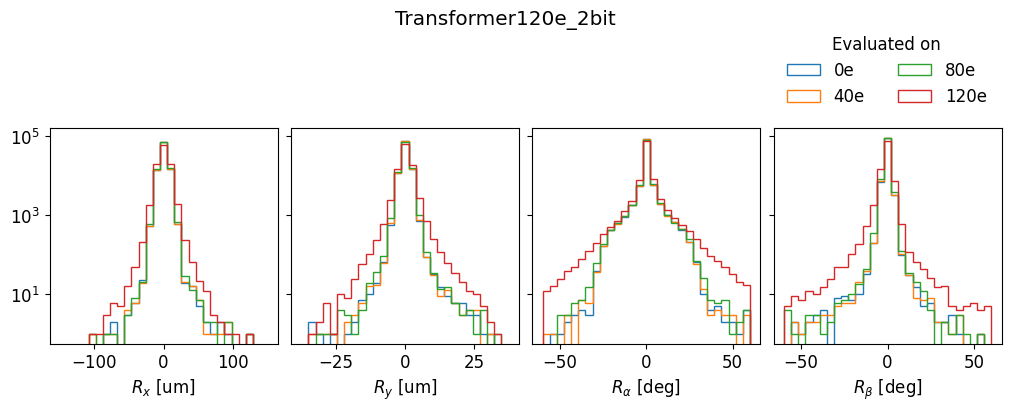

In [16]:
# OVERLAY RESIDUALS OF ALL TRAININGS --------------------------------------

# Pixel pitch (um)
xpitch = 50
ypitch = 12.5
# Thickness (um)
D = 100
# Size of pixel array
lenx = 16
leny = 16

fig, ax = plt.subplots(1,4,figsize=(10,4),sharey='row', constrained_layout=True)

for i,df in residuals.items():

    print(i)

    # x
    ax[0].set_xlabel(r'$R_x$ [um]')
    ax[0].hist(df["residualx"],histtype='step',bins=np.linspace(-3*xpitch,3*xpitch,30),color=colors[i])
    ax[0].set_yscale('log')

    # y
    ax[1].set_xlabel(r'$R_y$ [um]')
    ax[1].hist(df["residualy"],histtype='step',bins=np.linspace(-3*ypitch,3*ypitch,30),color=colors[i])

    # alpha
    ax[2].set_xlabel(r'$R_\alpha$ [deg]')
    ax[2].hist(df["residualA"],histtype='step',bins=np.linspace(-60,60,30),color=colors[i])
    
    # beta
    ax[3].set_xlabel(r'$R_\beta$ [deg]')
    ax[3].hist(df["residualB"],histtype='step',bins=np.linspace(-60,60,30),color=colors[i])

plt.suptitle(training_name);

plt.legend(labels=['0e','40e','80e','120e'],frameon=False,bbox_to_anchor=[1,1.5],ncols=2,title='Evaluated on')
    
#plt.tight_layout()
#plt.savefig('plots/'+training_name+'_residuals.png')